# 3a — QRF Sweeps (v2.0)

Hyperparameter optimisation and feature analysis for the **Quantile Regression Forest** model.

| § | Stage | Description | Est. wall time |
|---|---|---|---|
| 2 | **Param sweep** | Monte Carlo over `PARAM_GRID` | 2–4 h |
| 3 | **Feature ablation** | LOO ΔR² | ~20 min |
| 4 | **MC feature subset** | Random subset R² | 3–5 h |
| 5 | **Greedy forward** | Iterative best-feature build | 2–4 h |

Outputs → `output/sweeps/qrf_*.csv` | Figures → `fig/sweeps/qrf_*.png`

Best params written to `output/sweeps/qrf_params.json` (imported by `4_MODEL.ipynb`).

## 0. Toggles

In [ ]:
RUN_PARAM_SWEEP    = True
RUN_ABLATION       = True
RUN_MONTE_CARLO    = True
RUN_GREEDY_FORWARD = True

CALIBRATION_FRAC   = 0.20
MC_MIN_FEATS       = 5
MC_MAX_FEATS       = None
PARAM_RANDOM_SEED  = 2026
MC_RANDOM_SEED     = 2025
GREEDY_RANDOM_SEED = 2025

## 1. Imports & setup

In [ ]:
import sys, json, time, warnings, platform, psutil, datetime
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from pathlib import Path
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from joblib import Parallel, delayed

from config import *

optuna.logging.set_verbosity(optuna.logging.WARNING)

sweep_dir.mkdir(parents=True, exist_ok=True)
(fig_root / 'sweeps').mkdir(parents=True, exist_ok=True)
fig_sweep = fig_root / 'sweeps'

print(f"sweep_dir : {sweep_dir}")
print(f"fig_sweep : {fig_sweep}")

✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
sweep_dir : output/sweeps
fig_sweep : fig/sweeps


### 1a. Verify parquet

In [3]:
df_check = pd.read_parquet(parquet_ref, columns=obs_model + ['q'])
missing_m = [c for c in obs_model if c not in df_check.columns]
all_nan_m = [c for c in obs_model if df_check[c].isna().all()]
assert not missing_m, f'MISSING from parquet: {missing_m}'
assert not all_nan_m, f'ALL-NaN columns: {all_nan_m}'
print(f'\u2713 {len(obs_model)} obs_model features verified | q_clip_max={q_clip_max}')


✓ 21 obs_model features verified | q_clip_max=0.35


### 1b. Load reference data

In [4]:
obs_sel = obs_sweep  # NOTE: adjust here to test a different feature universe

df_ref    = pd.read_parquet(parquet_ref)
available = [f for f in obs_sel if f in df_ref.columns]
missing   = [f for f in obs_sel if f not in df_ref.columns]
if missing:
    warnings.warn(f'obs_sel columns missing from parquet: {missing}')
    raise RuntimeError(f'Missing features: {missing}')

cols_needed = available + ['q']
if 'weight' in df_ref.columns:
    cols_needed.append('weight')

work = (df_ref[cols_needed]
        .replace([np.inf, -np.inf], np.nan)
        .dropna())
work = work[(work['q'] >= q_clip_min) & (work['q'] <= q_clip_max)]

y_phys = work['q'].values
w_all  = work['weight'].values if 'weight' in work.columns else np.ones(len(work))
X_all  = work[available].values

print(f'Reference rows : {len(work):,}')
print(f'Features       : {len(available)}')
print(available)


Reference rows : 30,847
Features       : 22
['REVEAL_VP90VS60', 'REVEAL_S70', 'EMAG2_LOG', 'FREE_AIR', 'BOUGUER', 'MOHO_GRAV', 'REVEAL_S90', 'MOHO', 'GEOID', 'LAB', 'SI', 'MAG_SEIS_MOHO', 'REVEAL_S80', 'CTD', 'CRUST_RHO', 'SEDIMENT', 'REVEAL_VP50VS80', 'LITH_RHO', 'DEM', 'REVEAL_VP60VS70', 'REVEAL_S100', 'REVEAL_P150']


### 1c. Train / calibration split

In [5]:
from quantile_forest import RandomForestQuantileRegressor

(X_train, X_cal,
 y_train_phys, y_cal_phys,
 w_train, _) = train_test_split(
    X_all, y_phys, w_all,
    test_size=CALIBRATION_FRAC,
    random_state=random_state,
)
print(f'Train : {len(X_train):,}   Cal : {len(X_cal):,}')


Train : 24,677   Cal : 6,170


---
## 2. QRF Parameter Sweep

Monte Carlo search over `PARAM_GRID` from `config.py`. Saves every 5 runs; resumes from existing CSV.

In [6]:
param_csv     = sweep_dir / 'qrf_param_results.csv'
t_param_start = time.time()

if param_csv.exists():
    param_rows = pd.read_csv(param_csv).to_dict('records')
    print(f'Resuming from {len(param_rows)} existing runs.')
else:
    param_rows = []

runs_needed  = PARAM_N_RUNS - len(param_rows)
already_done = len(param_rows)   # offset so RNG seeds never repeat on resume

def _run_one_param(run_offset):
    rng      = np.random.default_rng(PARAM_RANDOM_SEED + run_offset)
    params   = {k: rng.choice(v) for k, v in PARAM_GRID.items()}
    use_log  = bool(params['use_log_target'])
    clip_max = float(params['q_clip_max'])
    cal_frac = float(params['cal_frac'])

    mask = y_phys <= clip_max
    X_run, y_run, w_run = X_all[mask], y_phys[mask], w_all[mask]
    X_tr, X_ca, y_tr_phys, y_ca_phys, w_tr, _ = train_test_split(
        X_run, y_run, w_run, test_size=cal_frac, random_state=random_state)

    y_tr  = np.log(y_tr_phys) if use_log else y_tr_phys
    sc    = StandardScaler()
    X_trs = sc.fit_transform(X_tr)
    X_cas = sc.transform(X_ca)

    mf     = params['max_features']
    if mf not in ('sqrt', 'log2'):
        mf = float(mf)
    md_val = None if params['max_depth'] is None else int(params['max_depth'])

    qrf = RandomForestQuantileRegressor(
        n_estimators     = int(params['n_estimators']),
        max_depth        = md_val,
        min_samples_leaf = int(params['min_samples_leaf']),
        max_features     = mf,
        random_state     = random_state,
        n_jobs           = 1)          # ← 1 here; parallelism is across runs
    t0 = time.time()
    qrf.fit(X_trs, y_tr, sample_weight=w_tr)
    elapsed = time.time() - t0

    preds_raw  = qrf.predict(X_cas, quantiles=[0.05, 0.50, 0.95])
    preds_phys = np.clip(np.exp(preds_raw) if use_log else preds_raw, q_clip_min, q_clip_max)
    p05, p50, p95 = preds_phys.T

    return dict(
        run              = already_done + run_offset + 1,
        n_estimators     = int(params['n_estimators']),
        max_depth        = str(params['max_depth']),
        min_samples_leaf = int(params['min_samples_leaf']),
        max_features     = str(params['max_features']),
        use_log_target   = use_log,
        q_clip_max       = clip_max,
        cal_frac         = cal_frac,
        n_train          = len(X_tr),
        n_cal            = len(X_ca),
        rmse             = float(np.sqrt(mean_squared_error(y_ca_phys, p50))),
        mae              = float(mean_absolute_error(y_ca_phys, p50)),
        r2               = float(r2_score(y_ca_phys, p50)),
        picp             = float(np.mean((y_ca_phys >= p05) & (y_ca_phys <= p95))),
        elapsed_s        = elapsed,
    )

if RUN_PARAM_SWEEP and runs_needed > 0:
    print(f'Runs to do: {runs_needed}  (n_jobs=-1, prefer=threads)')
    new_rows = Parallel(n_jobs=-1, prefer='threads', verbose=5)(
        delayed(_run_one_param)(i) for i in range(runs_needed)
    )
    param_rows.extend(new_rows)
    param_df = pd.DataFrame(param_rows)
    param_df.to_csv(param_csv, index=False)
    # summary print (sorted by R²)
    for row in sorted(new_rows, key=lambda r: r['r2'], reverse=True)[:10]:
        print(f'  run={row["run"]:3d}  log={row["use_log_target"]}  '
              f'depth={row["max_depth"]:4s}  leaf={row["min_samples_leaf"]:2d}  '
              f'mf={row["max_features"]:4s}  clip={row["q_clip_max"]:.3f}  '
              f'R²={row["r2"]:.4f}  RMSE={row["rmse"]*1000:.2f}  t={row["elapsed_s"]:.0f}s')
    print(f'Complete. Saved {param_csv}')

elif not RUN_PARAM_SWEEP and param_csv.exists():
    param_df = pd.read_csv(param_csv)
    print(f'Loaded {param_csv}  ({len(param_df)} runs)')
else:
    param_df = pd.read_csv(param_csv) if param_csv.exists() else None
    print(f'Already at {PARAM_N_RUNS} runs.')

t_param_end = time.time()

Runs to do: 200  (n_jobs=-1, prefer=threads)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed: 24.8min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed: 67.7min


  run= 78  log=False  depth=50    leaf= 5  mf=0.7   clip=0.200  R²=0.4930  RMSE=21.05  t=326s
  run= 30  log=False  depth=40    leaf= 3  mf=log2  clip=0.200  R²=0.4923  RMSE=21.06  t=122s
  run=197  log=False  depth=20    leaf= 2  mf=0.4   clip=0.200  R²=0.4922  RMSE=21.07  t=424s
  run=142  log=False  depth=40    leaf= 5  mf=0.5   clip=0.200  R²=0.4898  RMSE=21.12  t=424s
  run= 80  log=False  depth=50    leaf= 3  mf=0.3   clip=0.200  R²=0.4897  RMSE=21.12  t=322s
  run= 87  log=False  depth=None  leaf= 5  mf=sqrt  clip=0.200  R²=0.4854  RMSE=21.21  t=216s
  run=165  log=False  depth=25    leaf= 2  mf=0.5   clip=0.200  R²=0.4780  RMSE=21.56  t=159s
  run= 59  log=False  depth=50    leaf=10  mf=0.7   clip=0.200  R²=0.4768  RMSE=21.38  t=512s
  run= 15  log=False  depth=30    leaf=10  mf=0.7   clip=0.200  R²=0.4764  RMSE=21.39  t=533s
  run= 19  log=False  depth=25    leaf= 3  mf=log2  clip=0.200  R²=0.4701  RMSE=21.74  t=178s
Complete. Saved output/sweeps/qrf_param_results.csv


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 90.7min finished


### 2a. Parameter sensitivity

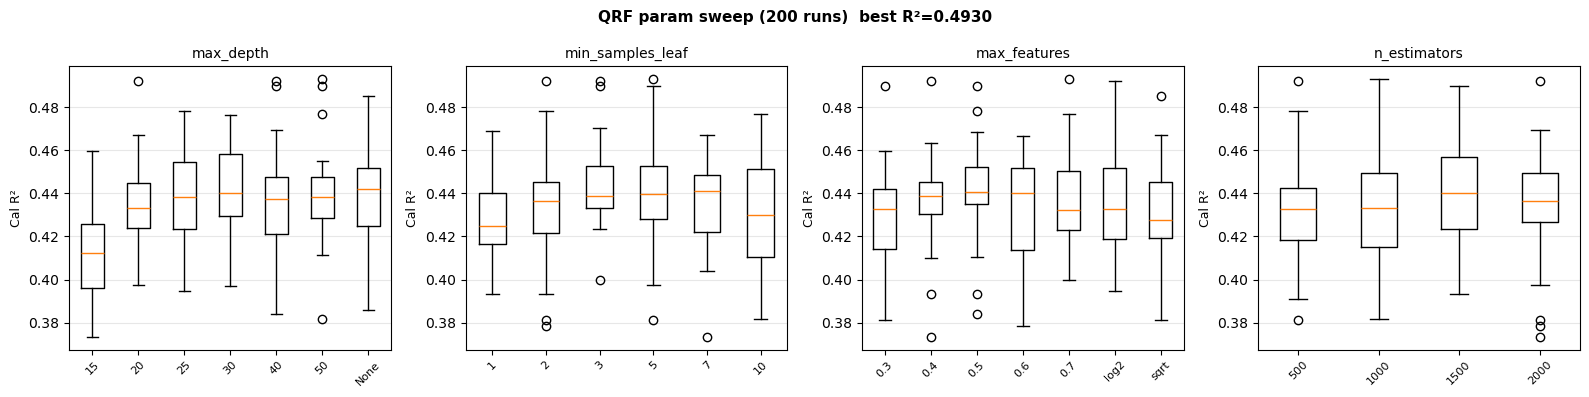

Saved fig/sweeps/qrf_param_sensitivity.png


In [7]:
if param_df is not None and len(param_df) > 0:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, param in zip(axes, ['max_depth','min_samples_leaf','max_features','n_estimators']):
        grouped = param_df.groupby(param)['r2']
        labels  = [str(k) for k in grouped.groups.keys()]
        data    = [grouped.get_group(k).values for k in grouped.groups.keys()]
        ax.boxplot(data, tick_labels=labels, vert=True)
        ax.set_title(param, fontsize=10);  ax.set_ylabel('Cal R²', fontsize=9)
        ax.tick_params(axis='x', labelsize=8, rotation=45);  ax.grid(True, axis='y', alpha=0.3)
    fig.suptitle(f'QRF param sweep ({len(param_df)} runs)  best R²={param_df.r2.max():.4f}',
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    fig.savefig(fig_sweep / 'qrf_param_sensitivity.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show();  print(f'Saved {fig_sweep}/qrf_param_sensitivity.png')


---
## 3. Feature Ablation (LOO)

`HELPFUL` = dropping this feature lowers R² by >0.002.

In [8]:
ablation_csv = sweep_dir / 'qrf_ablation_results.csv'
t_abl_start  = time.time()


def _qrf_eval(feat_idx):
    X_tr = X_train[:, feat_idx];  X_ca = X_cal[:, feat_idx]
    sc   = StandardScaler()
    qrf  = RandomForestQuantileRegressor(
        n_estimators     = QRF_N_ESTIMATORS,
        max_features     = QRF_MAX_FEATURES,
        max_depth        = QRF_MAX_DEPTH,
        min_samples_leaf = QRF_MIN_SAMPLES_LEAF,
        random_state     = random_state,
        n_jobs           = 1)      
    qrf.fit(sc.fit_transform(X_tr), y_train_phys, sample_weight=w_train)
    preds_raw  = qrf.predict(sc.transform(X_ca), quantiles=[0.05, 0.50, 0.95])
    preds_phys = np.clip(preds_raw, q_clip_min, q_clip_max)
    p05, p50, p95 = preds_phys.T
    return dict(
        r2  = float(r2_score(y_cal_phys, p50)),
        rmse= float(np.sqrt(mean_squared_error(y_cal_phys, p50))),
        picp= float(np.mean((y_cal_phys >= p05) & (y_cal_phys <= p95))))


all_idx = list(range(len(available)))
print('Training QRF baseline...')
baseline    = _qrf_eval(all_idx)
baseline_r2 = baseline['r2']
print(f'  RMSE={baseline["rmse"]*1000:.2f} mW/m²  R²={baseline_r2:.4f}  PICP={baseline["picp"]:.4f}')
print(f'  Est. LOO time (parallel): ~{len(available) * 10 / 60 / 8:.0f} min on 8 cores')


if RUN_ABLATION:
    n = len(available)

    def _abl_one(i, feat):
        idx_keep = [j for j in range(n) if j != i]
        res      = _qrf_eval(idx_keep)
        delta    = res['r2'] - baseline_r2
        tag      = 'HELPFUL' if delta < -0.002 else ('HARMFUL' if delta > 0.002 else 'neutral')
        return dict(feature=feat, r2_without=res['r2'], delta_r2=delta, verdict=tag)

    abl_rows = Parallel(n_jobs=-1, prefer='threads', verbose=5)(
        delayed(_abl_one)(i, feat) for i, feat in enumerate(available)
    )

    abl_df = pd.DataFrame(abl_rows).sort_values('delta_r2')
    abl_df.to_csv(ablation_csv, index=False)

    for row in abl_df.itertuples():
        print(f'  drop {row.feature:28s}  R²={row.r2_without:.4f}  '
              f'Δ={row.delta_r2:+.4f}  {row.verdict}')
    print(f'\nSaved {ablation_csv}')

elif ablation_csv.exists():
    abl_df = pd.read_csv(ablation_csv);  print(f'Loaded {ablation_csv}')
else:
    abl_df = None;  print('No saved results — set RUN_ABLATION = True.')


t_abl_end = time.time()

Training QRF baseline...
  RMSE=34.38 mW/m²  R²=0.4140  PICP=0.9128
  Est. LOO time (parallel): ~0 min on 8 cores


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  22 | elapsed: 13.2min remaining: 59.5min
[Parallel(n_jobs=-1)]: Done   9 out of  22 | elapsed: 13.3min remaining: 19.2min
[Parallel(n_jobs=-1)]: Done  14 out of  22 | elapsed: 22.0min remaining: 12.5min
[Parallel(n_jobs=-1)]: Done  19 out of  22 | elapsed: 22.9min remaining:  3.6min


  drop REVEAL_S70                    R²=0.4085  Δ=-0.0055  HELPFUL
  drop REVEAL_VP60VS70               R²=0.4089  Δ=-0.0051  HELPFUL
  drop GEOID                         R²=0.4094  Δ=-0.0046  HELPFUL
  drop MOHO                          R²=0.4097  Δ=-0.0043  HELPFUL
  drop REVEAL_VP50VS80               R²=0.4107  Δ=-0.0033  HELPFUL
  drop REVEAL_VP90VS60               R²=0.4110  Δ=-0.0030  HELPFUL
  drop SEDIMENT                      R²=0.4113  Δ=-0.0027  HELPFUL
  drop EMAG2_LOG                     R²=0.4115  Δ=-0.0025  HELPFUL
  drop FREE_AIR                      R²=0.4117  Δ=-0.0023  HELPFUL
  drop DEM                           R²=0.4117  Δ=-0.0023  HELPFUL
  drop BOUGUER                       R²=0.4119  Δ=-0.0021  HELPFUL
  drop MOHO_GRAV                     R²=0.4126  Δ=-0.0013  neutral
  drop LAB                           R²=0.4140  Δ=-0.0000  neutral
  drop MAG_SEIS_MOHO                 R²=0.4141  Δ=+0.0001  neutral
  drop SI                            R²=0.4142  Δ=+0.0002  neu

[Parallel(n_jobs=-1)]: Done  22 out of  22 | elapsed: 22.9min finished


### 3a. Ablation figure

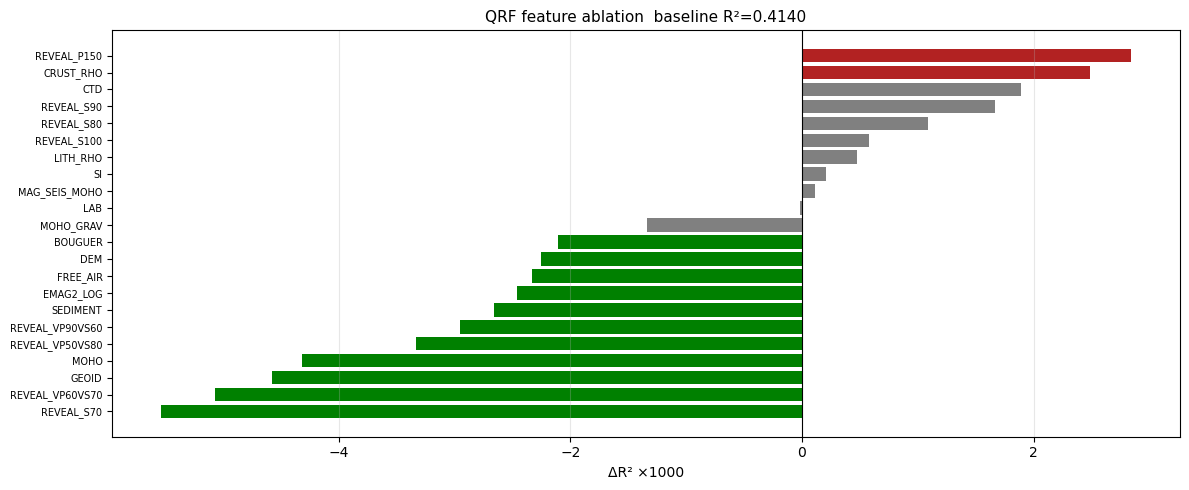

Saved fig/sweeps/qrf_ablation.png


In [9]:
if abl_df is not None and len(abl_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['green' if v=='HELPFUL' else ('firebrick' if v=='HARMFUL' else 'grey')
              for v in abl_df['verdict']]
    ax.barh(abl_df['feature'], abl_df['delta_r2']*1000, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('ΔR² ×1000', fontsize=10)
    ax.set_title(f'QRF feature ablation  baseline R²={baseline_r2:.4f}', fontsize=11)
    ax.tick_params(axis='y', labelsize=7);  ax.grid(True, axis='x', alpha=0.3)
    fig.tight_layout()
    fig.savefig(fig_sweep/'qrf_ablation.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show();  print(f'Saved {fig_sweep}/qrf_ablation.png')


---
## 4. MC Feature-Subset Sweep

In [11]:
mc_csv         = sweep_dir / 'qrf_mc_results.csv'
t_mc_start     = time.time()
rng_mc         = np.random.default_rng(MC_RANDOM_SEED)
mc_max         = len(available) - 1 if MC_MAX_FEATS is None else MC_MAX_FEATS
mc_rows        = pd.read_csv(mc_csv).to_dict('records') if mc_csv.exists() else []
mc_runs_needed = MC_N_RUNS - len(mc_rows)

if RUN_MONTE_CARLO and mc_runs_needed > 0:
    print(f'MC runs to do: {mc_runs_needed}')

    # Pre-generate all random feature subsets deterministically
    tasks = []
    for _ in range(mc_runs_needed):
        k       = int(rng_mc.integers(MC_MIN_FEATS, mc_max + 1))
        idx_sel = sorted(rng_mc.choice(len(available), size=k, replace=False).tolist())
        tasks.append(idx_sel)

    def _mc_one(idx_sel):
        res = _qrf_eval(idx_sel)
        return dict(
            n_feats  = len(idx_sel),
            features = '|'.join(available[i] for i in idx_sel),
            r2       = res['r2'],
            rmse     = res['rmse'])

    new_rows = Parallel(n_jobs=-1, prefer='threads', verbose=5)(
        delayed(_mc_one)(idx_sel) for idx_sel in tasks
    )

    mc_rows.extend(new_rows)
    mc_df = pd.DataFrame(mc_rows)
    mc_df.to_csv(mc_csv, index=False)
    print(f'Complete. Saved {mc_csv}')

elif mc_csv.exists():
    mc_df = pd.read_csv(mc_csv);  print(f'Loaded {mc_csv}')
else:
    mc_df = None;  print('No saved results — set RUN_MONTE_CARLO = True.')

t_mc_end = time.time()

MC runs to do: 300


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed: 39.5min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed: 100.5min
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed: 196.4min


Complete. Saved output/sweeps/qrf_mc_results.csv


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 217.5min finished


### 4a. MC figure

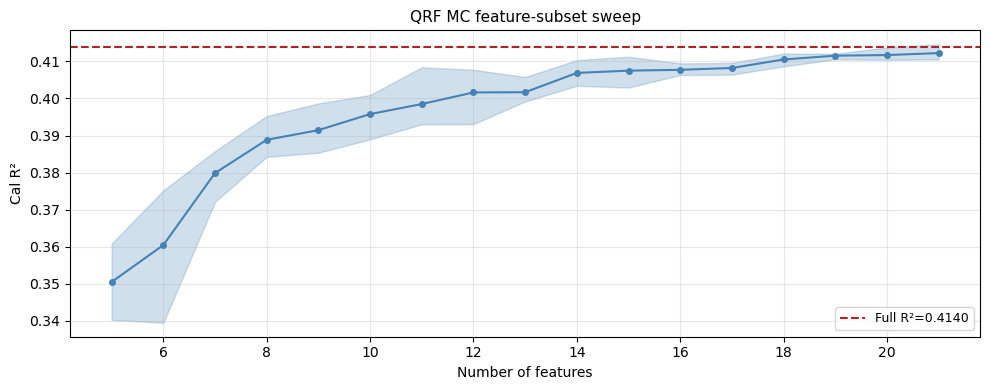

Saved fig/sweeps/qrf_mc_subset.png


In [12]:
if mc_df is not None and len(mc_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    grouped = mc_df.groupby('n_feats')['r2']
    x = sorted(grouped.groups.keys())
    ax.plot(x, [grouped.get_group(k).mean() for k in x], 'o-', ms=4, lw=1.5, color='steelblue')
    ax.fill_between(x, [grouped.get_group(k).quantile(0.25) for k in x],
                    [grouped.get_group(k).quantile(0.75) for k in x], alpha=0.25, color='steelblue')
    ax.axhline(baseline_r2, color='firebrick', lw=1.5, ls='--', label=f'Full R²={baseline_r2:.4f}')
    ax.set_xlabel('Number of features', fontsize=10);  ax.set_ylabel('Cal R²', fontsize=10)
    ax.set_title('QRF MC feature-subset sweep', fontsize=11)
    ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(fig_sweep/'qrf_mc_subset.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show();  print(f'Saved {fig_sweep}/qrf_mc_subset.png')


---
## 5. Greedy Forward Selection

In [13]:
greedy_csv  = sweep_dir / 'qrf_greedy_forward.csv'
t_gr_start  = time.time()

if RUN_GREEDY_FORWARD:
    greedy_rows  = []
    remaining    = list(range(len(available)))
    selected_idx = []

    def _greedy_candidate(i):
        res = _qrf_eval(selected_idx + [i])
        return i, available[i], res['r2']

    while remaining:
        results = Parallel(n_jobs=-1, prefer='threads')(
            delayed(_greedy_candidate)(i) for i in remaining
        )
        best_i, best_feat, best_r2 = max(results, key=lambda x: x[2])

        selected_idx.append(best_i)
        remaining.remove(best_i)
        greedy_rows.append(dict(
            step           = len(selected_idx),
            feature_added  = best_feat,
            n_feats        = len(selected_idx),
            r2             = best_r2,
            features_so_far= '|'.join(available[i] for i in selected_idx)))
        print(f'  step {len(selected_idx):2d}  +{best_feat:28s}  R²={best_r2:.4f}')

    greedy_df = pd.DataFrame(greedy_rows)
    greedy_df.to_csv(greedy_csv, index=False)
    print(f'\nSaved {greedy_csv}')

elif greedy_csv.exists():
    greedy_df = pd.read_csv(greedy_csv);  print(f'Loaded {greedy_csv}')
else:
    greedy_df = None;  print('No saved results — set RUN_GREEDY_FORWARD = True.')

t_gr_end = time.time()

  step  1  +MOHO_GRAV                     R²=0.1730
  step  2  +REVEAL_S80                    R²=0.2696
  step  3  +MOHO                          R²=0.3541
  step  4  +GEOID                         R²=0.3816
  step  5  +REVEAL_P150                   R²=0.3935
  step  6  +DEM                           R²=0.4016
  step  7  +SEDIMENT                      R²=0.4129
  step  8  +MAG_SEIS_MOHO                 R²=0.4145
  step  9  +BOUGUER                       R²=0.4155
  step 10  +EMAG2_LOG                     R²=0.4191
  step 11  +FREE_AIR                      R²=0.4210
  step 12  +REVEAL_S100                   R²=0.4229
  step 13  +LITH_RHO                      R²=0.4228
  step 14  +REVEAL_VP60VS70               R²=0.4217
  step 15  +REVEAL_S70                    R²=0.4217
  step 16  +CTD                           R²=0.4216
  step 17  +REVEAL_VP90VS60               R²=0.4216
  step 18  +CRUST_RHO                     R²=0.4199
  step 19  +REVEAL_VP50VS80               R²=0.4168
  step 20  +

### 5a. Greedy curve

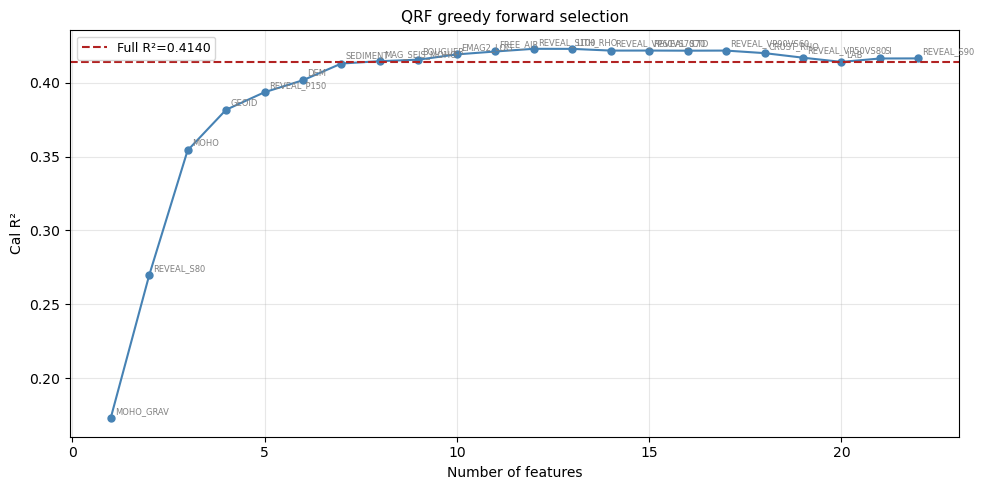

Saved fig/sweeps/qrf_greedy_curve.png


In [14]:
if greedy_df is not None and len(greedy_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(greedy_df['n_feats'], greedy_df['r2'], 'o-', ms=5, color='steelblue', lw=1.5)
    ax.axhline(baseline_r2, color='firebrick', lw=1.5, ls='--', label=f'Full R²={baseline_r2:.4f}')
    for _, row in greedy_df.iterrows():
        ax.annotate(row['feature_added'], xy=(row['n_feats'], row['r2']),
                    xytext=(3,3), textcoords='offset points', fontsize=6, color='grey')
    ax.set_xlabel('Number of features', fontsize=10);  ax.set_ylabel('Cal R²', fontsize=10)
    ax.set_title('QRF greedy forward selection', fontsize=11)
    ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(fig_sweep/'qrf_greedy_curve.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show();  print(f'Saved {fig_sweep}/qrf_greedy_curve.png')


In [17]:
# ---
# ## 5b. Decide obs_sel_final
#
# Strategy (in priority order):
#   1. Greedy elbow  — keep features while marginal ΔR² ≥ ELBOW_MIN_GAIN
#   2. LOO filter    — remove any HARMFUL features from the greedy set
#   3. MC sanity     — print the MC envelope plateau as a cross-check
#   4. Manual override — edit obs_sel_final below if needed

ELBOW_MIN_GAIN = 0.002   # min marginal R² gain to keep adding a feature

# ── 1. Greedy elbow ────────────────────────────────────────────────────────────
if greedy_df is not None and len(greedy_df) > 0:
    g = greedy_df.copy().sort_values('step').reset_index(drop=True)
    g['marginal_r2'] = g['r2'].diff().fillna(g['r2'].iloc[0])
    elbow_mask = g['marginal_r2'] >= ELBOW_MIN_GAIN
    if elbow_mask.any():
        elbow_step = int(g.loc[elbow_mask, 'step'].max())
    else:
        elbow_step = int(g['step'].max())   # fallback: keep all
    greedy_sel = g[g['step'] <= elbow_step]['feature_added'].tolist()
    print(f'Greedy elbow at step {elbow_step}  ({len(greedy_sel)} features)')
    print(f'  R² at elbow : {g.loc[g["step"]==elbow_step, "r2"].values[0]:.4f}')
    print(f'  R² full     : {g["r2"].iloc[-1]:.4f}')
    for _, row in g[g['step'] <= elbow_step].iterrows():
        print(f'  step {int(row["step"]):2d}  +{row["feature_added"]:28s}  '
              f'R²={row["r2"]:.4f}  ΔR²={row["marginal_r2"]:+.4f}')
else:
    greedy_sel = list(available)
    print('greedy_df not available — falling back to full available list')

# ── 2. LOO filter ──────────────────────────────────────────────────────────────
if abl_df is not None:
    harmful = set(abl_df[abl_df['verdict'] == 'HARMFUL']['feature'].tolist())
    filtered = [f for f in greedy_sel if f not in harmful]
    if harmful & set(greedy_sel):
        print(f'\nLOO filter removed {len(harmful & set(greedy_sel))} HARMFUL feature(s): '
              f'{sorted(harmful & set(greedy_sel))}')
    else:
        print('\nLOO filter: no HARMFUL features in greedy set — nothing removed')
else:
    filtered = greedy_sel
    print('\nabl_df not available — skipping LOO filter')

# ── 3. MC sanity ───────────────────────────────────────────────────────────────
if mc_df is not None and len(mc_df) > 0:
    mc_grouped = mc_df.groupby('n_feats')['r2']
    mc_means   = {k: mc_grouped.get_group(k).mean() for k in mc_grouped.groups}
    mc_plateau = max(mc_means, key=mc_means.get)
    print(f'\nMC envelope: best mean R² at k={mc_plateau} features '
          f'(R²={mc_means[mc_plateau]:.4f}) — greedy elbow at k={len(greedy_sel)}')

# ── 4. Validate selected subset R² ────────────────────────
idx_sel  = [available.index(f) for f in filtered]
res_sel  = _qrf_eval(idx_sel)
print(f'\nSelected subset  : {len(filtered)} features  '
      f'R²={res_sel["r2"]:.4f}  RMSE={res_sel["rmse"]*1000:.2f} mW/m²')
print(f'Full model       : {len(available)} features  '
      f'R²={baseline_r2:.4f}')
print(f'Δ (subset−full)  : {res_sel["r2"] - baseline_r2:+.4f}')

obs_sel_final = filtered   # or: obs_sel_final = ['FEATURE_A', 'FEATURE_B', ...]

print(f'\nobs_sel_final ({len(obs_sel_final)} features): {obs_sel_final}')

Greedy elbow at step 21  (21 features)
  R² at elbow : 0.4163
  R² full     : 0.4164
  step  1  +MOHO_GRAV                     R²=0.1730  ΔR²=+0.1730
  step  2  +REVEAL_S80                    R²=0.2696  ΔR²=+0.0966
  step  3  +MOHO                          R²=0.3541  ΔR²=+0.0846
  step  4  +GEOID                         R²=0.3816  ΔR²=+0.0275
  step  5  +REVEAL_P150                   R²=0.3935  ΔR²=+0.0119
  step  6  +DEM                           R²=0.4016  ΔR²=+0.0081
  step  7  +SEDIMENT                      R²=0.4129  ΔR²=+0.0113
  step  8  +MAG_SEIS_MOHO                 R²=0.4145  ΔR²=+0.0016
  step  9  +BOUGUER                       R²=0.4155  ΔR²=+0.0010
  step 10  +EMAG2_LOG                     R²=0.4191  ΔR²=+0.0036
  step 11  +FREE_AIR                      R²=0.4210  ΔR²=+0.0020
  step 12  +REVEAL_S100                   R²=0.4229  ΔR²=+0.0018
  step 13  +LITH_RHO                      R²=0.4228  ΔR²=-0.0000
  step 14  +REVEAL_VP60VS70               R²=0.4217  ΔR²=-0.0012
  ste

---
## 6. Write `qrf_params.json`

In [18]:
qrf_json = param_paths['qrf']

if param_df is not None and len(param_df) > 0:
    best_row = param_df.loc[param_df['r2'].idxmax()]
    best_qrf = dict(
        model='QRF', sweep_notebook='3a_QRF_SWEEP',
        best_r2_cal=float(best_row['r2']),
        n_estimators=int(best_row['n_estimators']),
        max_depth=None if str(best_row['max_depth'])=='None' else int(best_row['max_depth']),
        min_samples_leaf=int(best_row['min_samples_leaf']),
        max_features=float(best_row['max_features'])
                     if best_row['max_features'] not in ('sqrt','log2')
                     else best_row['max_features'],
        use_log_target=bool(best_row['use_log_target']),
        q_clip_max=float(best_row['q_clip_max']),
        cal_frac=float(best_row['cal_frac']),
        obs_sel=obs_sel_final, n_sweep_runs=len(param_df),
    )
    with open(qrf_json, 'w') as fp: json.dump(best_qrf, fp, indent=2)
    print(f'Saved {qrf_json}')
    for k, v in best_qrf.items():
        if k != 'obs_sel': print(f'  {k:22s} {v}')
else:
    print('No param_df available — run §2 first.')


Saved output/sweeps/qrf_params.json
  model                  QRF
  sweep_notebook         3a_QRF_SWEEP
  best_r2_cal            0.4929642295624892
  n_estimators           1000
  max_depth              50
  min_samples_leaf       5
  max_features           0.7
  use_log_target         False
  q_clip_max             0.2
  cal_frac               0.1
  n_sweep_runs           200


---
## 7. Runtime log

In [ ]:
def _safe(x):
    try: return float(x)
    except: return None

log_df = pd.DataFrame([
    dict(stage='qrf_param_sweep',    wall_s=_safe(locals().get('t_param_end',0) - locals().get('t_param_start',0))),
    dict(stage='qrf_ablation_loo',   wall_s=_safe(locals().get('t_abl_end',0)   - locals().get('t_abl_start',0))),
    dict(stage='qrf_mc_subset',      wall_s=_safe(locals().get('t_mc_end',0)     - locals().get('t_mc_start',0))),
    dict(stage='qrf_greedy_forward', wall_s=_safe(locals().get('t_gr_end',0)     - locals().get('t_gr_start',0))),
])
log_df['wall_min'] = (log_df['wall_s'] / 60).round(2)
log_df.to_csv(sweep_dir/'qrf_runtime_log.csv', index=False)
print(log_df[['stage','wall_min']].to_string(index=False))
print(f'Saved {sweep_dir}/qrf_runtime_log.csv')
